# scratchkit — Bayesian Methods, from scratch

Every Bayesian algorithm in [`scratchkit`](https://pypi.org/project/scratchkit/)
(`import mlscratch`) — implemented from scratch in pure NumPy. These are
the algorithms most "from scratch" tutorials skip, because they're
harder to get right: proper uncertainty quantification, not just point
predictions.

**Algorithms covered:** Gaussian / Multinomial / Bernoulli Naive Bayes,
Bayesian Linear Regression, Gaussian Process Regression, Hidden Markov
Models, Kalman Filters, Bayesian Networks, Bayesian Neural Networks.


In [ ]:
!pip install -q scratchkit

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine, load_breast_cancer
from sklearn.feature_extraction.text import CountVectorizer

from mlscratch.bayesian import (
    GaussianNB, MultinomialNB, BernoulliNB,
    BayesianLinearRegression,
    GaussianProcessRegressor, RBFKernel, Matern52Kernel, PeriodicKernel,
    HiddenMarkovModel,
    KalmanFilter,
    BayesianNetwork,
    BayesianNeuralNetwork,
)
from mlscratch.preprocessing import StandardScaler, train_test_split
from mlscratch.metrics import accuracy_score

np.random.seed(0)
plt.rcParams["figure.figsize"] = (7, 4)
print("scratchkit imports OK")


scratchkit imports OK


## 1. Naive Bayes — three flavours, three data types

The "naive" assumption (features independent given the class) lets each
flavour fit a different distribution per feature:

| Class | Assumes features are... | Typical use |
|---|---|---|
| `GaussianNB` | continuous, normally distributed | real-valued measurements |
| `MultinomialNB` | counts | word/token counts (text) |
| `BernoulliNB` | binary presence/absence | bag-of-words "did this word appear" |


In [3]:
# --- GaussianNB on real, continuous data (Wine) ---
wine = load_wine()
Xw_train, Xw_test, yw_train, yw_test = train_test_split(wine.data, wine.target, test_size=0.25, random_state=0)
gnb = GaussianNB().fit(Xw_train, yw_train)
print(f"GaussianNB on Wine:        test accuracy = {accuracy_score(yw_test, gnb.predict(Xw_test)):.3f}")


GaussianNB on Wine:        test accuracy = 1.000


In [4]:
# --- MultinomialNB on real text (word counts) ---
texts = [
    "win money now claim your free prize",
    "limited offer click here to win cash",
    "free lottery winner claim prize today",
    "congratulations you won a free gift card",
    "meeting scheduled for tomorrow at noon",
    "please review the attached project report",
    "can we reschedule our call to friday",
    "thanks for sending over the quarterly numbers",
]
labels = np.array([1, 1, 1, 1, 0, 0, 0, 0])  # 1 = spam, 0 = ham

vectorizer = CountVectorizer()
X_counts = vectorizer.fit_transform(texts).toarray()  # word-count features (data prep only)

mnb = MultinomialNB(alpha=1.0).fit(X_counts, labels)

test_texts = ["free cash prize click now", "let's meet to discuss the report"]
X_test_counts = vectorizer.transform(test_texts).toarray()
preds = mnb.predict(X_test_counts)
for text, pred in zip(test_texts, preds):
    print(f"MultinomialNB: {'SPAM' if pred else 'HAM ':<5} <- \"{text}\"")


MultinomialNB: SPAM  <- "free cash prize click now"
MultinomialNB: HAM   <- "let's meet to discuss the report"


In [5]:
# --- BernoulliNB on real data, binarized (Breast Cancer: feature above/below its median) ---
bc = load_breast_cancer()
Xb_train, Xb_test, yb_train, yb_test = train_test_split(bc.data, bc.target, test_size=0.25, stratify=bc.target, random_state=0)

bnb = BernoulliNB(binarize=np.median(Xb_train, axis=0).mean()).fit(Xb_train, yb_train)
print(f"BernoulliNB on Breast Cancer (binarized): test accuracy = {accuracy_score(yb_test, bnb.predict(Xb_test)):.3f}")


BernoulliNB on Breast Cancer (binarized): test accuracy = 0.874


## 2. Bayesian Linear Regression — predictions *with* uncertainty

Ordinary linear regression gives you a point estimate. Bayesian linear
regression gives you a full posterior over the weights, so every
prediction comes with a calibrated standard deviation — wider far from
the training data, narrower close to it.

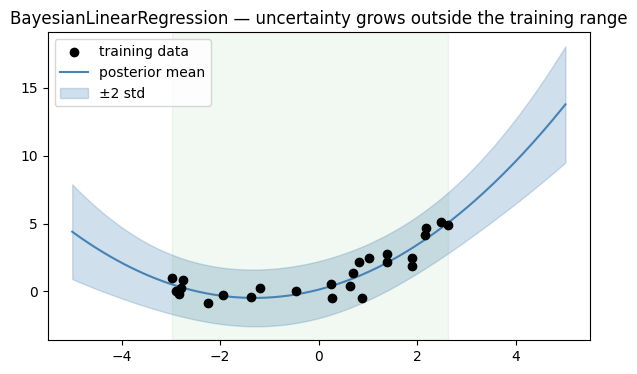

In [6]:
rng = np.random.default_rng(0)
x = np.sort(rng.uniform(-3, 3, 25))
y = 0.6 * x + 0.3 * x**2 + rng.normal(0, 1.0, 25)
X_design = np.column_stack([x, x**2])  # let the model see x and x^2

blr = BayesianLinearRegression(alpha=1.0, beta=1.0).fit(X_design, y)

x_grid = np.linspace(-5, 5, 200)  # deliberately wider than the training range
X_grid_design = np.column_stack([x_grid, x_grid**2])
mean, std = blr.predict(X_grid_design, return_std=True)

plt.scatter(x, y, color="black", zorder=5, label="training data")
plt.plot(x_grid, mean, color="steelblue", label="posterior mean")
plt.fill_between(x_grid, mean - 2 * std, mean + 2 * std, alpha=0.25, color="steelblue", label="±2 std")
plt.axvspan(x.min(), x.max(), alpha=0.05, color="green")
plt.title("BayesianLinearRegression — uncertainty grows outside the training range")
plt.legend()
plt.show()


## 3. Gaussian Process Regression — non-parametric, kernel-driven uncertainty

A GP places a prior directly over *functions*; the kernel encodes what
"similar" inputs mean. We fit the same noisy data with three different
kernels to see how the choice of kernel changes the fitted function's
character.

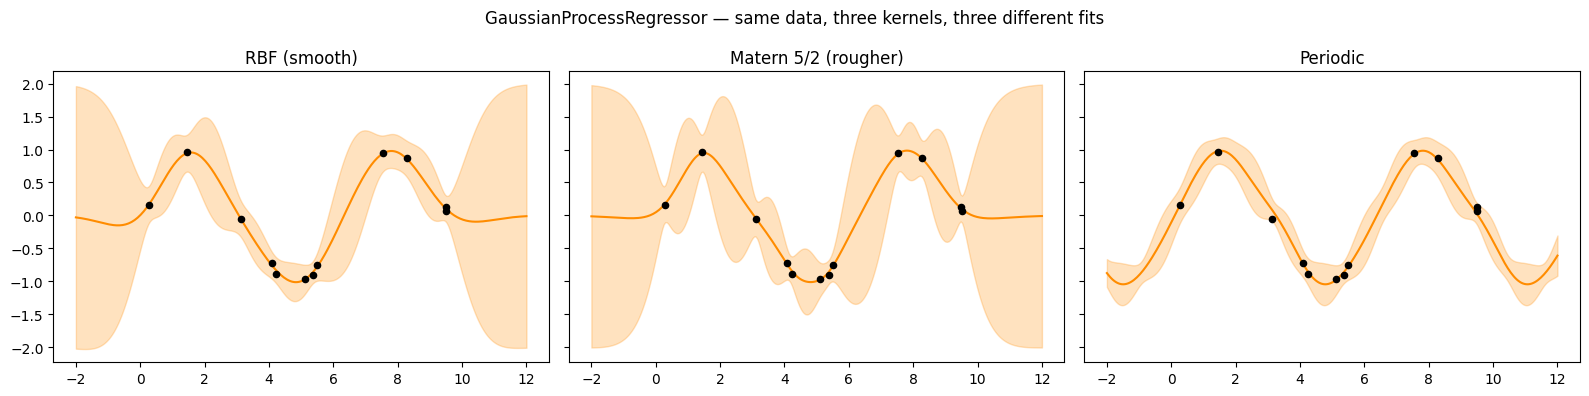

In [7]:
rng = np.random.default_rng(1)
x_obs = np.sort(rng.uniform(0, 10, 12))
y_obs = np.sin(x_obs) + rng.normal(0, 0.15, len(x_obs))
x_grid = np.linspace(-2, 12, 300)

kernels = {
    "RBF (smooth)":        RBFKernel(length_scale=1.0),
    "Matern 5/2 (rougher)": Matern52Kernel(length_scale=1.0),
    "Periodic":             PeriodicKernel(length_scale=1.0, period=6.28),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (name, kernel) in zip(axes, kernels.items()):
    gp = GaussianProcessRegressor(kernel=kernel, noise_variance=0.02).fit(x_obs.reshape(-1, 1), y_obs)
    mean, std = gp.predict(x_grid.reshape(-1, 1), return_std=True)
    ax.plot(x_grid, mean, color="darkorange")
    ax.fill_between(x_grid, mean - 2 * std, mean + 2 * std, alpha=0.25, color="darkorange")
    ax.scatter(x_obs, y_obs, color="black", zorder=5, s=20)
    ax.set_title(name)
plt.suptitle("GaussianProcessRegressor — same data, three kernels, three different fits")
plt.tight_layout()
plt.show()


## 4. Hidden Markov Model — the "occasionally dishonest casino"

The textbook HMM example (Durbin et al.): a casino mostly uses a fair
die, but occasionally swaps in a loaded one. You only see the rolls
(observations) — never which die was in play (the hidden state). We
generate rolls from a *known* two-die process, then use Viterbi
decoding to recover which die was actually used at each roll, and EM
(`fit`) to re-estimate the model's parameters from data alone.

Viterbi-decoded hidden state matches the true (simulated) die 63.5% of the time


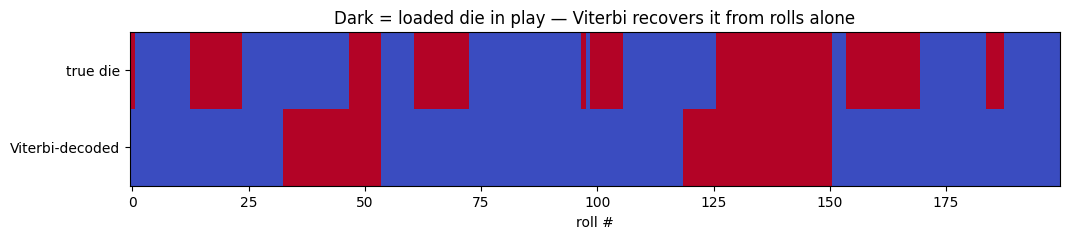


Learned transition matrix (rows should look 'sticky', like the true one):
[[0.87 0.13]
 [0.56 0.44]]


In [8]:
true_hmm = HiddenMarkovModel(n_states=2, n_observations=6, random_state=0)
true_hmm.pi = np.array([0.5, 0.5])
true_hmm.A = np.array([[0.95, 0.05],     # state 0 = fair die, sticky
                        [0.10, 0.90]])    # state 1 = loaded die, sticky
true_hmm.B = np.array([
    [1/6, 1/6, 1/6, 1/6, 1/6, 1/6],       # fair die: uniform
    [0.10, 0.10, 0.10, 0.10, 0.10, 0.50], # loaded die: heavily favors a "6" (index 5)
])

true_states, observed_rolls = true_hmm.sample(200, random_state=0)

decoded_states = true_hmm.viterbi(observed_rolls)
agreement = np.mean(decoded_states == true_states)
print(f"Viterbi-decoded hidden state matches the true (simulated) die {agreement:.1%} of the time")

fig, ax = plt.subplots(figsize=(12, 2))
ax.imshow([true_states, decoded_states], aspect="auto", cmap="coolwarm")
ax.set_yticks([0, 1]); ax.set_yticklabels(["true die", "Viterbi-decoded"])
ax.set_xlabel("roll #")
ax.set_title("Dark = loaded die in play — Viterbi recovers it from rolls alone")
plt.show()

# Re-estimate an HMM's parameters from observations only, via EM
learned_hmm = HiddenMarkovModel(n_states=2, n_observations=6, random_state=0)
learned_hmm.fit([observed_rolls], n_iter=50)
print(f"\nLearned transition matrix (rows should look 'sticky', like the true one):\n{learned_hmm.A.round(2)}")


## 5. Kalman Filter — tracking a moving object from noisy position readings

Classic constant-velocity model: state is `[position, velocity]`, but
we only ever *observe* a noisy position (like a noisy GPS reading).
The Kalman filter fuses the motion model with each new noisy
measurement to produce a smooth, much more accurate position and
velocity estimate.

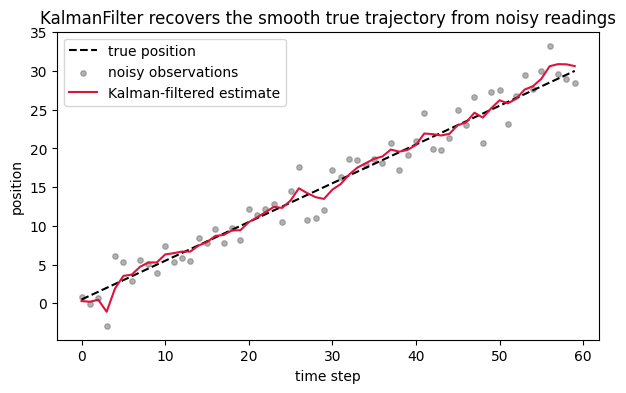

RMSE, raw noisy readings:   2.00
RMSE, Kalman-filtered:      0.79


In [9]:
dt = 1.0
F = np.array([[1.0, dt], [0.0, 1.0]])   # constant-velocity motion model
H = np.array([[1.0, 0.0]])               # we only observe position
Q = np.eye(2) * 0.01                     # process noise (small — motion model is trusted)
R = np.array([[4.0]])                    # observation noise (noisy "GPS")

rng = np.random.default_rng(2)
n_steps = 60
true_velocity = 0.5
true_position = np.cumsum(np.full(n_steps, true_velocity))
noisy_observations = true_position + rng.normal(0, 2.0, n_steps)

kf = KalmanFilter(F, H, Q, R, x0=np.array([0.0, 0.0]), P0=np.eye(2))
kf.filter(noisy_observations.reshape(-1, 1))
filtered_position = kf.x_filt_[:, 0]

plt.plot(true_position, "k--", label="true position")
plt.scatter(range(n_steps), noisy_observations, s=15, color="gray", alpha=0.6, label="noisy observations")
plt.plot(filtered_position, color="crimson", label="Kalman-filtered estimate")
plt.legend(); plt.xlabel("time step"); plt.ylabel("position")
plt.title("KalmanFilter recovers the smooth true trajectory from noisy readings")
plt.show()

rmse_raw = np.sqrt(np.mean((noisy_observations - true_position) ** 2))
rmse_filtered = np.sqrt(np.mean((filtered_position - true_position) ** 2))
print(f"RMSE, raw noisy readings:   {rmse_raw:.2f}")
print(f"RMSE, Kalman-filtered:      {rmse_filtered:.2f}")


## 6. Bayesian Network — exact inference on the classic Sprinkler network

Judea Pearl's textbook example: does the grass get wet because it
rained, because the sprinkler ran, or both? A Bayesian Network encodes
the causal structure and conditional probability tables, then answers
*any* probability query by exact inference — including the famous
"explaining away" effect.

In [10]:
bn = BayesianNetwork()
bn.add_variable("Rain", 2)
bn.add_variable("Sprinkler", 2, parents=["Rain"])
bn.add_variable("WetGrass", 2, parents=["Rain", "Sprinkler"])

bn.set_cpt("Rain", np.array([0.8, 0.2]))                          # P(Rain=F), P(Rain=T)
bn.set_cpt("Sprinkler", np.array([[0.6, 0.4],                     # Rain=F: P(S=F), P(S=T)
                                   [0.99, 0.01]]))                 # Rain=T: sprinklers rarely run when it's already raining
bn.set_cpt("WetGrass", np.array([
    [[1.0, 0.0], [0.1, 0.9]],    # Rain=F: [Sprinkler=F -> grass dry; Sprinkler=T -> usually wet]
    [[0.2, 0.8], [0.01, 0.99]],  # Rain=T: grass usually wet regardless of sprinkler
]))

p_rain = bn.query("Rain")
print(f"P(Rain)                          = {p_rain.round(3)}")

p_rain_given_wet = bn.query("Rain", evidence={"WetGrass": 1})
print(f"P(Rain | WetGrass=True)          = {p_rain_given_wet.round(3)}   <- seeing wet grass raises belief it rained")

p_rain_given_wet_and_sprinkler = bn.query("Rain", evidence={"WetGrass": 1, "Sprinkler": 1})
print(f"P(Rain | WetGrass=T, Sprinkler=T) = {p_rain_given_wet_and_sprinkler.round(3)}   <- 'explaining away': knowing the sprinkler ran lowers it back down")


P(Rain)                          = [0.8 0.2]
P(Rain | WetGrass=True)          = [0.642 0.358]   <- seeing wet grass raises belief it rained
P(Rain | WetGrass=T, Sprinkler=T) = [0.993 0.007]   <- 'explaining away': knowing the sprinkler ran lowers it back down


## 7. Bayesian Neural Network — classification that knows what it doesn't know

A standard MLP gives one number per class; a BNN places a distribution
over its *weights* and reports a distribution over predictions —
letting it express genuine uncertainty on inputs unlike anything it
was trained on.

In [11]:
from mlscratch.unsupervised import PCA

Xc_train, Xc_test, yc_train, yc_test = train_test_split(bc.data, bc.target, test_size=0.25, stratify=bc.target, random_state=0)
scaler = StandardScaler().fit(Xc_train)
Xc_train_s, Xc_test_s = scaler.transform(Xc_train), scaler.transform(Xc_test)

# Reduce to 6 PCA dims so the finite-difference BNN stays fast in this notebook
pca = PCA(n_components=6).fit(Xc_train_s)
Xc_bnn_train, Xc_bnn_test = pca.transform(Xc_train_s), pca.transform(Xc_test_s)
print(f"explained variance (6 PCs): {pca.explained_variance_ratio_.sum():.1%} of 30-feature information retained")

bnn = BayesianNeuralNetwork(hidden_sizes=[8], task='binary', n_epochs=15, lr=0.005, random_state=0)
bnn.fit(Xc_bnn_train, yc_train)

proba = bnn.predict_proba(Xc_bnn_test, n_samples=30)
preds = (proba >= 0.5).astype(int)
print(f"BayesianNeuralNetwork test accuracy: {accuracy_score(yc_test, preds):.3f}")

uncertainty = np.abs(proba - 0.5)  # distance from 50/50 — low = uncertain
most_uncertain = np.argsort(uncertainty)[:5]
print("\n5 test samples the model is LEAST confident about (proba closest to 0.5):")
for i in most_uncertain:
    print(f"  sample {i}: P(malignant)={proba[i]:.2f}, true label={yc_test[i]}")


explained variance (6 PCs): 88.9% of 30-feature information retained


BayesianNeuralNetwork test accuracy: 0.636

5 test samples the model is LEAST confident about (proba closest to 0.5):
  sample 50: P(malignant)=0.50, true label=0
  sample 44: P(malignant)=0.51, true label=1
  sample 83: P(malignant)=0.49, true label=0
  sample 123: P(malignant)=0.51, true label=0
  sample 59: P(malignant)=0.51, true label=0


## Next steps

- See **`01_supervised_learning.ipynb`** for regression, classification, and ensembles
- See **`02_unsupervised_learning.ipynb`** for clustering, PCA, t-SNE
- See **`04_reinforcement_learning.ipynb`** for Q-Learning through SAC
- See **`05_neural_networks.ipynb`** for MLPs, RNNs, CNNs, Transformers, and GANs

⭐ If this was useful, star the repo:
https://github.com/Mattral/ML-AI-Algorithms-from-scratch
